In [1]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Kết nối đến file db
from sqlalchemy import create_engine
import urllib
server = 'localhost,1433'
database = 'fintech'
username = 'sa'
password = 'huong6978'
connection_string = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password};'
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Đọc dữ liệu từ bảng bằng câu lệnh SQL
df = pd.read_sql_query("SELECT * FROM credit_risk_staging", engine)

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,loan_status
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,0.59,True,True
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0.10,False,False
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,0.57,False,True
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,0.53,False,True
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,0.55,True,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   person_age                 32581 non-null  int64  
 1   person_income              32581 non-null  int64  
 2   person_home_ownership      32581 non-null  object 
 3   person_emp_length          31686 non-null  float64
 4   loan_intent                32581 non-null  object 
 5   loan_amnt                  32581 non-null  int64  
 6   loan_int_rate              29465 non-null  float64
 7   loan_percent_income        32581 non-null  float64
 8   cb_person_default_on_file  32581 non-null  bool   
 9   loan_status                32581 non-null  bool   
dtypes: bool(2), float64(3), int64(3), object(2)
memory usage: 2.1+ MB


In [4]:
df.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             895
loan_intent                     0
loan_amnt                       0
loan_int_rate                3116
loan_percent_income             0
cb_person_default_on_file       0
loan_status                     0
dtype: int64

In [5]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.170203
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.106782
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.090000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.230000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.219999,0.830000


In [6]:
#Let's divide columns into two as numerical and categorical 
numerical_cols = df.select_dtypes(include = ["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include = ["object"]).columns

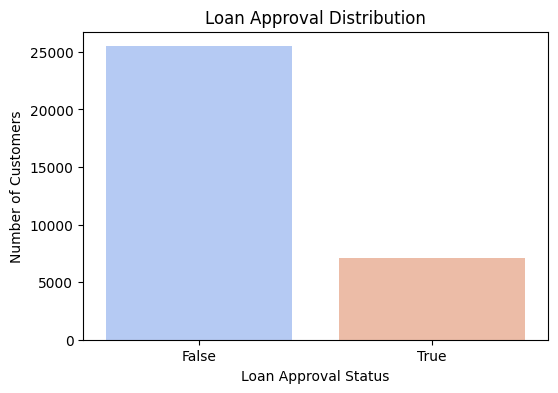

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df, palette="coolwarm")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approval Status")
plt.ylabel("Number of Customers")
plt.show()

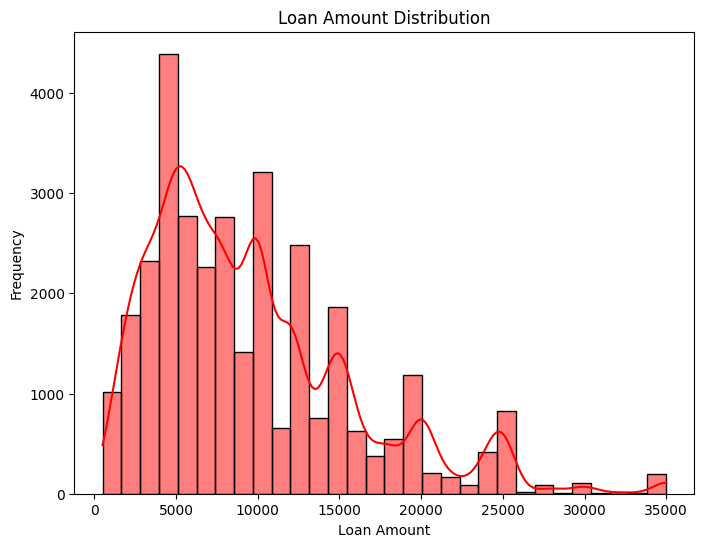

In [8]:
# Histogram for a numerical column like 'LoanAmount'
plt.figure(figsize=(8,6))
sns.histplot(df['loan_amnt'], bins=30, kde=True, color="red")
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

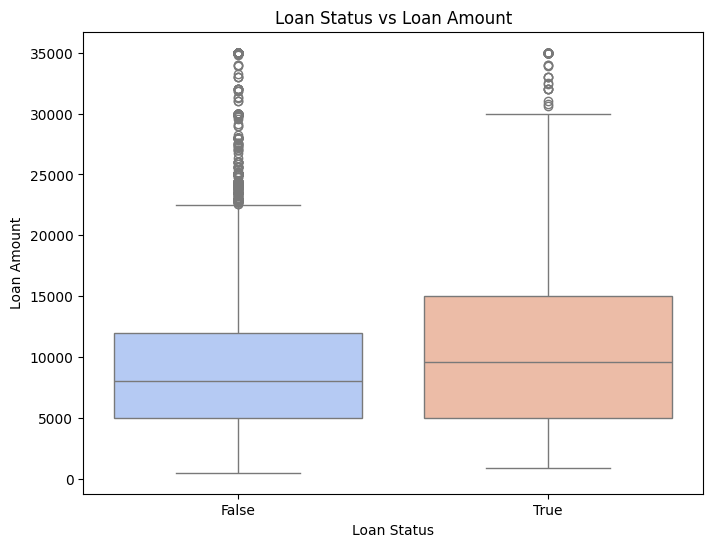

In [9]:
# Boxplot for Loan Status vs Loan Amount

plt.figure(figsize=(8,6))
sns.boxplot(x="loan_status", y="loan_amnt", data=df, palette="coolwarm")
plt.title('Loan Status vs Loan Amount')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()

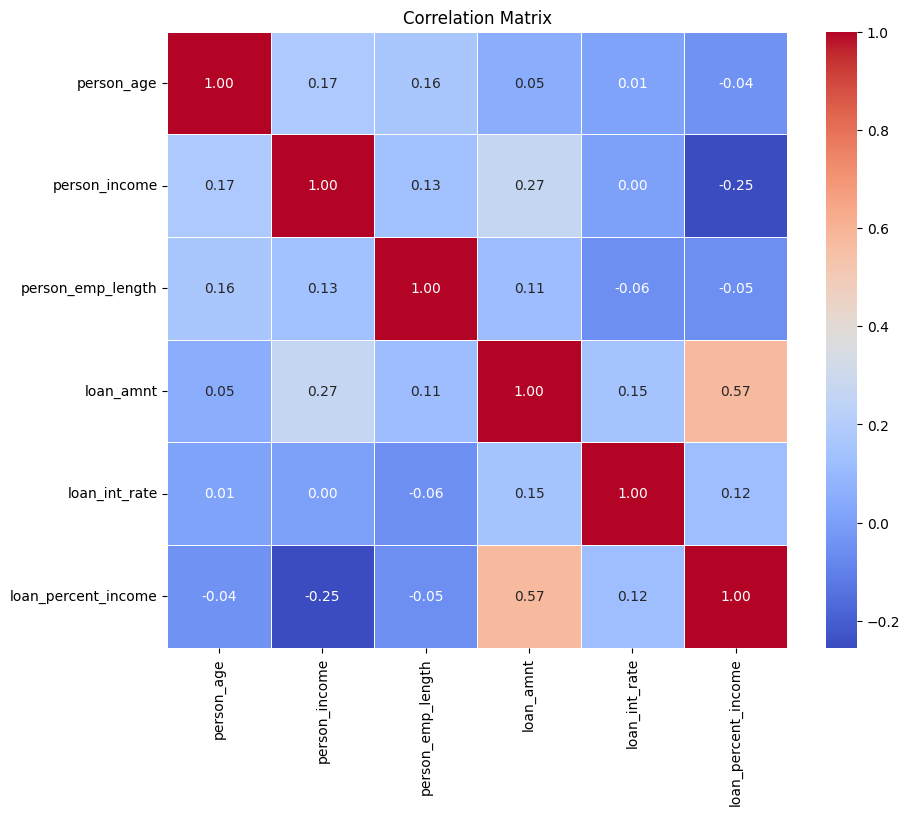

In [10]:
# Create the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

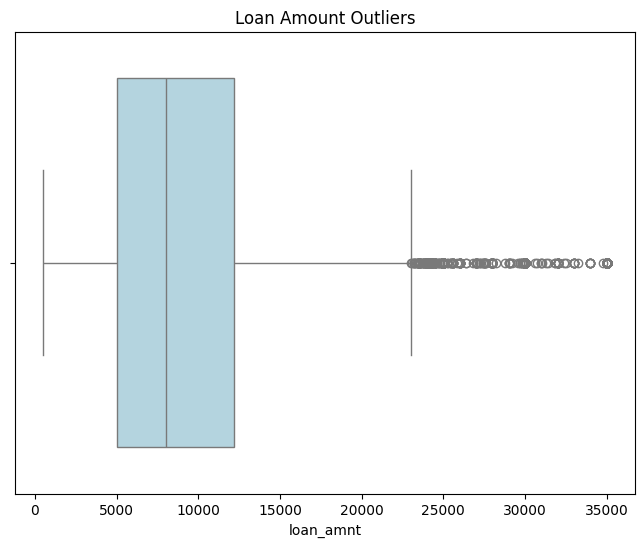

In [11]:
#Outliers in Loan Amount (Box Plot)
plt.figure(figsize=(8,6))
sns.boxplot(x=df['loan_amnt'], color='lightblue')
plt.title('Loan Amount Outliers')
plt.show()

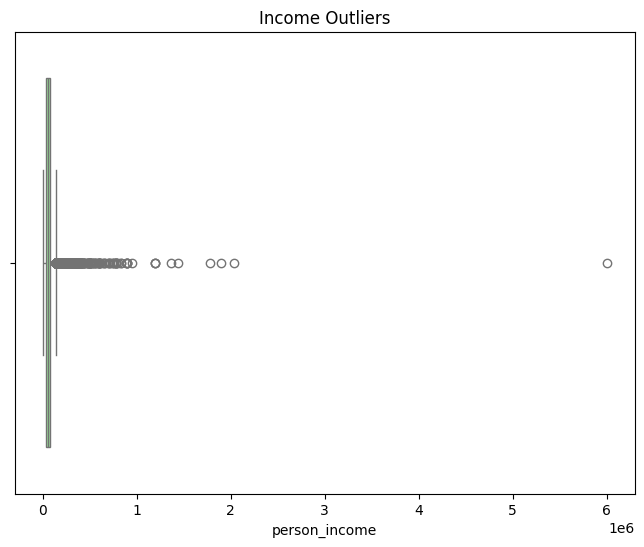

In [12]:
# Outliers in Income (Box Plot)

plt.figure(figsize=(8,6))
sns.boxplot(x=df['person_income'], color='lightgreen')
plt.title('Income Outliers')
plt.show()